## Module 4: Cancer

## Team Members:
Kai-Tang Tseng, Mohamed Elfaki

## Project Title:
Evaluating the impact of Cancer Hallmark : Angiogenesis on the progression of Gioblastoma (GBM)



## Project Goal:
This project aims to analyze the role of angiogenesis in glioblastoma (GBM) by examining the expression of angiogenic genes such as VEGFA in tumor datasets.

## Disease Background: 
Low-Grade Giloma (LGG - Grade 1,2) and Gilblastoma Multiforme (GBM - Grade 4)

### Gilblastoma Multiforme (also known as just Giloblastoma)'s Background Information

* Prevalence & incidence : Glioblastoma is the most common primary malignant brain tumor in adults, with an incidence of approximately 3–4 cases per 100,000 people per year. It has a very poor prognosis, with median survival around 12–15 months.

* Risk factors (genetic, lifestyle) & Societal determinants : isk factors include genetic mutations, prior exposure to radiation, and age (more common in older adults). Lifestyle factors are not strongly linked, but access to healthcare can influence diagnosis and outcomes.

* Standard of care treatments (& reimbursement) : Standard treatment includes surgical removal of the tumor followed by radiation therapy and chemotherapy (typically temozolomide). Despite treatment, recurrence is common due to the tumor’s aggressive nature.

* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology) : Glioblastoma grows rapidly and invades surrounding brain tissue. It promotes angiogenesis through factors like VEGFA, which stimulate blood vessel formation to supply nutrients and oxygen, supporting tumor survival and expansion. (There are some Giloblastoma, specifically Secondary Giloblastoma which can progress from a Low Grade Giloma (LGG) into Giloblastoma Multiforme. (Primary refers to the Giloblastoma just appears without LGG)) (Ohgaki & Kleihues, 2013)

### Cancer Hallmark : 

* Cancer hallmark focus: Angiogenesis

* Overview of hallmark: Angiogenesis is the process by which new blood vessels form from existing ones. In cancer, this allows tumors to receive oxygen and nutrients, enabling rapid growth and survival. Glioblastoma (GBM) is a highly aggressive brain tumor that relies heavily on angiogenesis to sustain its rapid progression.

* Genes associated with hallmark to be studied : VEGFA, VEGFB, KDR, CXCR1, CXCR2, HIF1A, PDGFB (Biterge-Sut,2020 & D'Alessio et al, 2016)


## Data-Set: 

In this study, we will analysis the subset of Low-Grade Glioma (LGG) and Glioblastoma Multiforme (GBM).

Our primarily objective is to analysis the angiogenesis gene difference between a LGG and Glioblastoma to see how the more aggressive Glioblastoma increase the angiogenesis factors, for this we will use subset of RNA Analysis to quantify the Gene Dosage in order to compare how the different cancer type hijake the vascular angiogenesis network differently in intensity.

Supplementary analysis using the metadata allows for comparing race and age to see if those factors can also play a role in the angiogenesis gene expression.

The data is collected from The Cancer Genome Atlas Program (TCGA) which collects the metadata and the RNA Gene Expression Data. For each cancer patients, a specific ID is assigned, and metadata such as background information including cancer stages, age, sex, and other informations are collected. Gene Expression Data is collected through RNA extraction from the patient's sample where the RNA is then sequenced and quantified using Next Generation Sequencing. Gene expression is measured in Transcripts Per Million (TPM), a unit that normalized for gene length. It is then further transformed using the following formula : $\log_{2}(\text{TPM} + 1)$ to reduce data skewness. (1 is added to handle zero-expression values).

The data can be access here : https://portal.gdc.cancer.gov/ 


## Data Analysis: 


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Define paths
metadata_path = r"C:\Users\kaits\OneDrive\Desktop\BME2315\Module-4-Cancer\data\TRAINING_SET_GSE62944_metadata.csv"
subsample_path = r"C:\Users\kaits\OneDrive\Desktop\BME2315\Module-4-Cancer\data\TRAINING_SET_GSE62944_subsample_log2TPM.csv"

# Load Metadata
data_metadata = pd.read_csv(metadata_path)

# Filter for LGG and GBM samples only
filtered_metadata = data_metadata[data_metadata['cancer_type'].isin(['LGG', 'GBM'])]
print(filtered_metadata)

                            sample cancer_type bcr_patient_barcode  gender  \
320   TCGA-HT-8011-01A-11R-2403-07         LGG        TCGA-HT-8011    MALE   
321   TCGA-RY-A83Y-01A-11R-A36H-07         LGG        TCGA-RY-A83Y    MALE   
322   TCGA-HT-7616-01A-11R-2256-07         LGG        TCGA-HT-7616    MALE   
323   TCGA-P5-A737-01A-11R-A32Q-07         LGG        TCGA-P5-A737    MALE   
324   TCGA-HT-7884-01B-11R-2403-07         LGG        TCGA-HT-7884  FEMALE   
...                            ...         ...                 ...     ...   
1515  TCGA-14-0781-01B-01R-1849-01         GBM        TCGA-14-0781    MALE   
1516  TCGA-06-0210-02A-01R-2005-01         GBM                 NaN     NaN   
1517  TCGA-14-1829-01A-01R-1850-01         GBM        TCGA-14-1829    MALE   
1518  TCGA-06-5856-01A-01R-1849-01         GBM        TCGA-06-5856    MALE   
1519  TCGA-32-2615-01A-01R-1850-01         GBM        TCGA-32-2615    MALE   

                           race               ethnicity age_at_

C:\Users\kaits\AppData\Local\Temp\ipykernel_14360\2078415562.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Cancer Type')


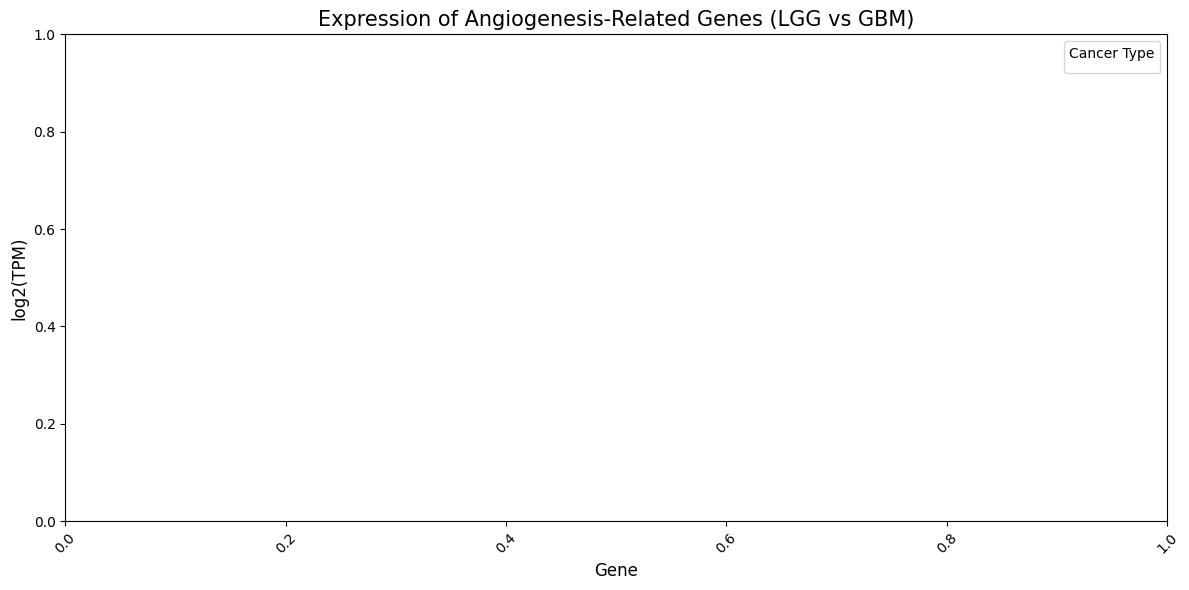

In [ ]:
# This is written largely with Gemini AI, still need does not work, a work in progress.
# The goal is to be able to look for specific gene expression in the specific filtered cancer.

import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter Metadata
# FIX: Ensure the column name is 'sample_id' or 'sample' based on your CSV
filtered_metadata = data_metadata[data_metadata['cancer_type'].isin(['LGG', 'GBM'])]
samples_to_keep = filtered_metadata['sample'].tolist() 

# 2. Load and Filter Expression Data
data_subsample = pd.read_csv(subsample_path)
genes_of_interest = ['VEGFA', 'VEGFB', 'KDR', 'CXCR1', 'CXCR2', 'HIF1A', 'PDGFB']

# FIX: gene_col should be the name of the FIRST column in your expression file
gene_col = data_subsample.columns[0] 

# Filter for the rows containing our genes
filtered_genes = data_subsample[data_subsample[gene_col].isin(genes_of_interest)]

# 3. Align Samples and Prepare for Plotting
# Keep only the gene column and the samples that exist in BOTH files
cols_to_keep = [gene_col] + [s for s in samples_to_keep if s in data_subsample.columns]
expression_filtered = filtered_genes[cols_to_keep]

# Convert from wide to long format for Seaborn
expression_melted = expression_filtered.melt(id_vars=gene_col, var_name='sample', value_name='Expression')

# Merge with metadata to get the cancer_type label
# FIX: 'on' must match the column name in both dataframes
plot_data = pd.merge(expression_melted, filtered_metadata[['sample', 'cancer_type']], on='sample')

# 4. Create the Bar Chart
plt.figure(figsize=(12, 6))

plt.title('Expression of Angiogenesis-Related Genes (LGG vs GBM)', fontsize=15)
plt.xlabel('Gene', fontsize=12)
plt.ylabel('log2(TPM)', fontsize=12)
plt.legend(title='Cancer Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Methods
The machine learning technique I am using is: *fill in and describe*

*What is this method optimizing? How does the model decide it is "good enough"?*

**

### Analysis
*(Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this can run your code to perform the analysis that you did, generate your figures, etc.)*

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*

## Bibliography : 

Biterge-Sut B. (2020). A comprehensive analysis of the angiogenesis-related genes in glioblastoma multiforme vs. brain lower grade glioma. Arquivos de neuro-psiquiatria, 78(1), 34–38. https://doi.org/10.1590/0004-282X20190131

D'Alessio, A., Proietti, G., Lama, G., Biamonte, F., Lauriola, L., Moscato, U., Vescovi, A., Mangiola, A., Angelucci, C., & Sica, G. (2016). Analysis of angiogenesis related factors in glioblastoma, peritumoral tissue and their derived cancer stem cells. Oncotarget, 7(48), 78541–78556. https://doi.org/10.18632/oncotarget.12398

Ohgaki, H., & Kleihues, P. (2013). The definition of primary and secondary glioblastoma. Clinical cancer research : an official journal of the American Association for Cancer Research, 19(4), 764–772. https://doi.org/10.1158/1078-0432.CCR-12-3002


